[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/drive/1zSrlNtmiEmp1cxfZhjeh7hCbmrB4MAcH#scrollTo=AXXT4Y1qj6fu)

## Clustering *mouse* dataset

We will visualise EM algorithm using the *mouse* dataset. It is an artificial dataset which is used to highlight advantages and disadvantages of various clustering algorithms.

  - 300 obserwacji z rozkładu $\mathcal{N}\left( \left( \begin{array}{c} 0 \\ 0 \end{array} \right), \left(\begin{array}{cc} 0.16 & 0 \\ 0 & 0.16 \end{array}\right)\right)$
  - 100 obserwacji z rozkładu $\mathcal{N}\left( \left( \begin{array}{c} 0.8 \\ 0.8 \end{array} \right), \left(\begin{array}{cc} 0.04 & 0 \\ 0 & 0.04 \end{array}\right)\right)$
  - 100 obserwacji z rozkładu $\mathcal{N}\left( \left( \begin{array}{c} -0.8 \\ 0.8 \end{array} \right), \left(\begin{array}{cc} 0.04 & 0 \\ 0 & 0.04 \end{array}\right)\right)$

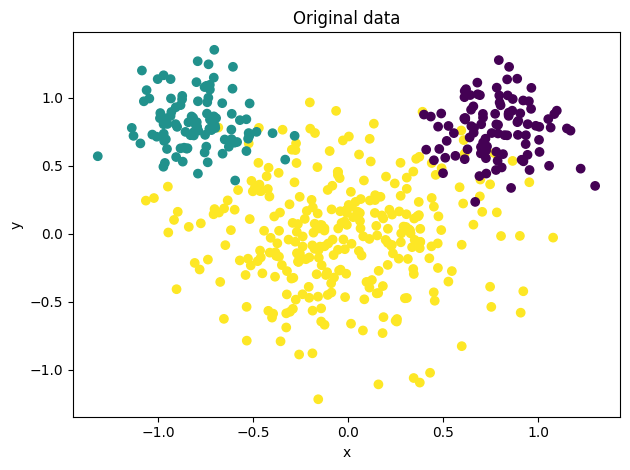

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Generate the "mouse" dataset
# ----------------------------------------------------------------------
np.random.seed(0)  # for reproducibility

# 1) 300 points from N([0, 0], [[0.16, 0],[0, 0.16]])
mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.16, 0.0],
                 [0.0,  0.16]])
data1 = np.random.multivariate_normal(mean1, cov1, 300)

# 2) 100 points from N([0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean2 = np.array([0.8, 0.8])
cov2 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data2 = np.random.multivariate_normal(mean2, cov2, 100)

# 3) 100 points from N([-0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean3 = np.array([-0.8, 0.8])
cov3 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data3 = np.random.multivariate_normal(mean3, cov3, 100)

# Combine all data
data_X = np.vstack([data1, data2, data3])
N, d = data_X.shape  # should be (500, 2)

# Plot the final state
plt.scatter(data_X[:,0], data_X[:,1], c=[2]*300+[0]*100+[1]*100, cmap='viridis')
#plt.scatter(data_X[:,0], data_X[:,1], cmap='viridis')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Original data")
plt.tight_layout()
plt.show()

## Estimating EM with Gaussian Mixture Algorithm

In [ ]:
from sklearn.mixture import GaussianMixture
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D  # Import Line2D for custom legend

model = GaussianMixture(n_components=3,  random_state=42, n_init=5)

gm_model = model.fit(data_X)
#print(gm_model.means_)
#print(gm_model.covariances_)


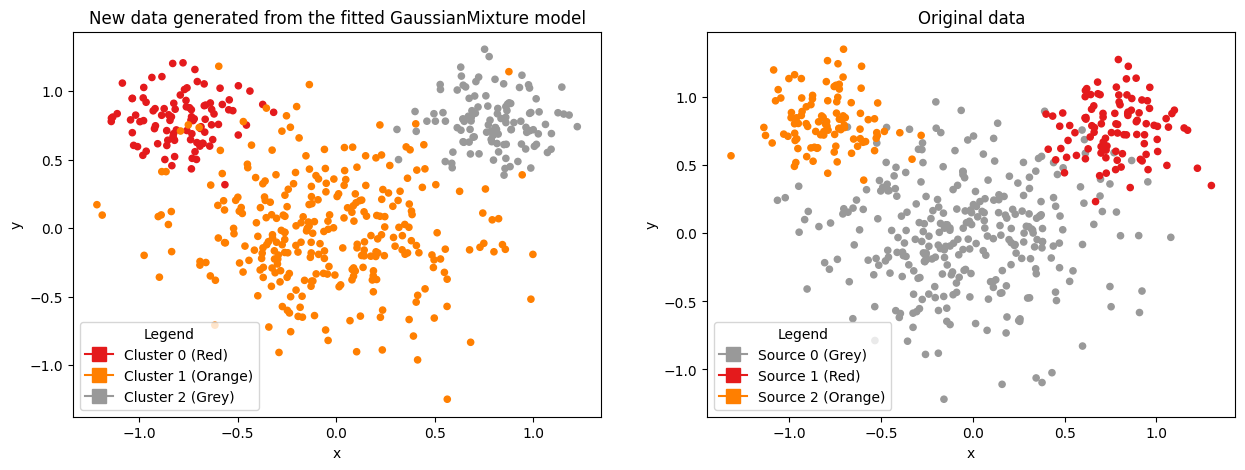

In [ ]:
norm = Normalize(vmin=0, vmax=2)  # Normalize colors between 0 and 2 - common color pallette

# 1. Generate 500 new points from the fitted GM model
X_new, new_labels = gm_model.sample(n_samples=500)

# 2. Visualize the newly generated data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(X_new[:, 0], X_new[:, 1], c=new_labels, cmap='Set1', s=20, norm=norm)
axes[0].set_title("New data generated from the fitted GaussianMixture model")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
legend_elements = [
    Line2D([0], [0], marker='s', color=plt.cm.Set1(0.0), markersize=10, label='Cluster 0 (Red)'),
    Line2D([0], [0], marker='s', color=plt.cm.Set1(0.5), markersize=10, label='Cluster 1 (Orange)'),
    Line2D([0], [0], marker='s', color=plt.cm.Set1(1.0), markersize=10, label='Cluster 2 (Grey)')
]

# Add legend to the plot
axes[0].legend(handles=legend_elements, loc='best', frameon=True, title="Legend")

# 3. Visualize the original data

axes[1].scatter(data_X[:, 0], data_X[:, 1], c=[2]*300+[0]*100+[1]*100, cmap='Set1', s=20, norm=norm)  #I shuffle the colors to match the inferred clusters
axes[1].set_title("Original data")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
legend_elements = [
    Line2D([0], [0], marker='s', color=plt.cm.Set1(1.0), markersize=10, label='Source 0 (Grey)'),
    Line2D([0], [0], marker='s', color=plt.cm.Set1(0.0), markersize=10, label='Source 1 (Red)'),
    Line2D([0], [0], marker='s', color=plt.cm.Set1(0.5), markersize=10, label='Source 2 (Orange)')
]

# Add legend to the plot
axes[1].legend(handles=legend_elements, loc='best', frameon=True, title="Legend")


plt.show()

# **Homework Assignment: EM Clustering in 2D**
-------------------------------

You have seen how the **Expectation-Maximization (EM)** algorithm can fit a Gaussian Mixture Model (GMM) to a 2D dataset. You should now explore:

## **Primary Question**

**How can we visualize the *decision boundary* for attributing a *new* (unlabeled) point to one of the GMM clusters?**  

In other words, given a 2D data distribution modeled by EM, think of a way to clearly show (on a plot) *which* cluster a point would be assigned to (or which cluster has the highest responsibility (posterior probability) for that point)?  

The plot should comprehensively cover the entire visible region, ensuring that for any point on the plot, it is immediately evident which cluster it would belong to. You can plot **lines** separating clusters or use a **color map** showing each point's "most likely cluster" (use at least 1000 points).

You can illustrate your approach with **the same** 2D dataset that we used in class, or you can find another suitable 2D dataset, it's up to you. Note however, that having 3 clusters enhances the clarity of the visualization—while 2 clusters result in overly simple boundaries, using 4 or more clusters can make the entire plot difficult to interpret. Try to choose a dataset with 3 clusters.

Discuss any irregularities observed in the resulting plot. If a decision boundary suggests that a region should be attributed to a cluster in a counterintuitive way (we saw it in class!), provide an explanation for why this might occur. It may be also an indication you have a bug in your code.

## **Secondary Question**

**If we *didn't know* the number of clusters in advance, how could we decide on a suitable $K$ for the clustering algorithm?**  

You would need an evaluation metrics, right? Experiment with inertia and silhoutte scores (and other metrics, if you'd like) and show the resulting plots.

You can illustrate your approach with **the same** dataset as in the primary question by trying different values of $K$. Or you can find another suitable dataset, it's up to you. Note, that the dataset doesn't need to be 2D in this task.


## **Task & Deliverables**

1. **Colab Notebook**  
   - Create a **Colab notebook** that:
     - Clearly **answers** both the **primary** and **secondary** questions with appropriate plots and short explanations.
     - Uses Python code (e.g. `scikit-learn` for GMM) to visualize:
       1. The **data** and **cluster assignments**.
       2. The **decision boundary** (lines or a color map) indicating each cluster's region.
       3. A demonstration of how you would pick a suitable number of clusters $K$ when it is not known, with plots.
   - Remember to use the `$` symbol to delimit **inline equations** and `$$` to delimit **full-line equations**.

2. **Publish on GitHub**  
   - Place the Colab notebook in your **GitHub repository** for this course.
   - In your repository’s **README**, add a **link** to the notebook and also include an **“Open in Colab”** badge at the top of the notebook so it can be launched directly from GitHub.



**Zadanie pierwsze, na podstawie "Mouse Dataset"**

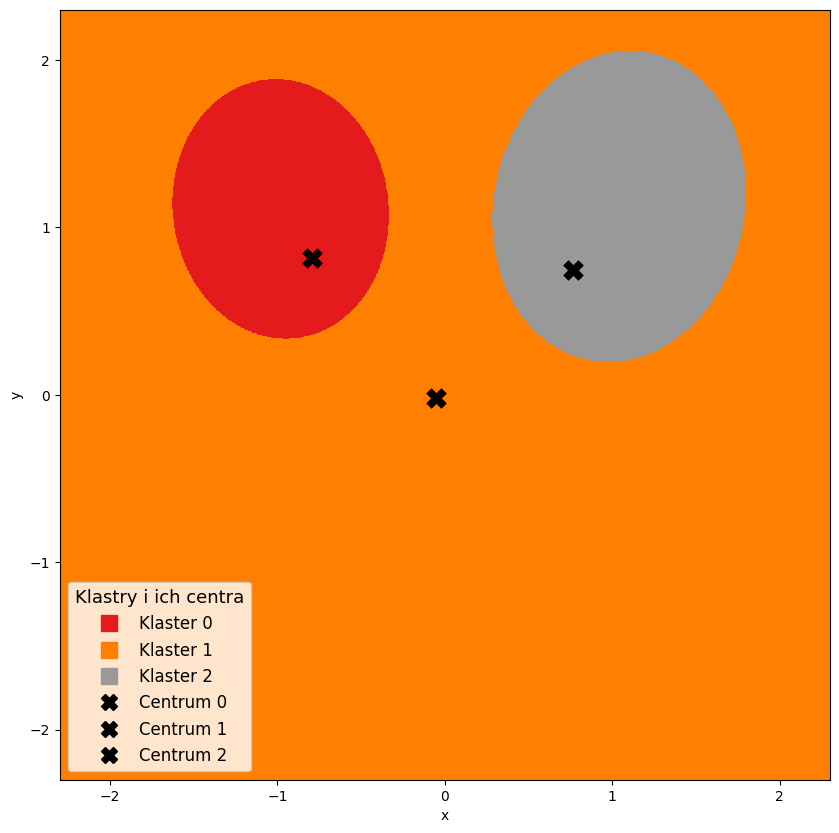

In [ ]:
# Siatka punktów
X_axis = np.linspace(-2.3, 2.3, 2000)
X, Y = np.meshgrid(X_axis, X_axis)
grid = np.column_stack([X.ravel(), Y.ravel()])

# Przewidywania modelu
Z = gm_model.predict(grid).reshape(X.shape)

fig, ax = plt.subplots(figsize=(10, 10))

# Mapa klastrów
im = ax.imshow(Z, extent=[X_axis.min(), X_axis.max(), X_axis.min(), X_axis.max()], origin='lower', cmap='Set1', interpolation='nearest', aspect='equal')
ax.set_xlabel("x")
ax.set_ylabel("y")

# Środki klastrów
centers = gm_model.means_
cmap = plt.cm.Set1

for k, (cx, cy) in enumerate(centers):
    ax.scatter(cx, cy, marker='X', s=200, color="black", edgecolor='black', linewidth=0.5, label=f"Centrum {k}")

# Legenda klastrów
unique_labels = np.unique(Z)

cluster_handles = [ plt.Line2D([], [], marker='s', color=cmap(label / max(unique_labels.max(), 1)), linestyle='', markersize=12, label=f"Klaster {label}")
                   for label in unique_labels]

# Markery centrów
center_handles = [plt.Line2D([], [], marker='X', color="black", linestyle='', markersize=12, label=f"Centrum {k}") for k in range(len(centers))]

ax.legend(handles=cluster_handles + center_handles, title="Klastry i ich centra", loc="lower left", frameon=True, fontsize=12, title_fontsize=13)

plt.show()


**Pytanie pierwsze - wizualizacja granic klastrów i ich interpretacja**

Aby zwizualizować granicę decyzyjną modelu Gaussian Mixture Model (GMM), wytrenowanego na używanym podczas zajęć "Mouse Dataset", wygenerowałem gęstą siatkę punktów pokrywającą cały obszar widoczny na wykresie. Dla każdego punktu obliczyłem, który komponent GMM ma największą wartość posterior probability, korzystając z funkcji 'predict'. Otrzymaną macierz etykiet wyświetliłem jako mapę kolorów, a na niej naniosłem środki klastrów oraz oryginalne dane.

Wynikowy wykres ujawnia kilka interesujących i nie do końca intuicyjnych zjawisk. Najbardziej rzucającą się w oczy cechą jest dominacja klastra centralnego (klastra 1) w dużej części przestrzeni. Klaster ten obejmuje nie tylko obszar wokół własnego środka, ale również niemal wszystkie punkty położone daleko od danych. W przeciwieństwie do niego dwa pozostałe klastry (0 i 2) mają bardzo ograniczone obszary wpływu, które obejmują jedynie okolice ich środków. Granice decyzyjne są wyraźnie asymetryczne i zakrzywione względem centrów kalstrów, a ich przebieg nie odpowiada intuicyjnemu „podziałowi przestrzeni na trzy obszary”.

Takie zachowanie jest naturalną konsekwencją właściwości modelu GMM. Klaster 1 ma największą wariancję spośród wszystkich trzech komponentów, ponieważ odpowiada największej grupie danych (300 punktów), podczas gdy pozostałe dwa klastry mają wariancję czterokrotnie mniejszą i obejmują tylko po 100 punktów. W modelu GMM wariancja bezpośrednio wpływa na to, jak szybko maleje gęstość Gaussa wraz z oddalaniem się od środka. Dwa małe klastry mają bardzo „wąskie” rozkłady, których gęstość spada gwałtownie, natomiast klaster 1 ma rozkład szeroki, którego ogony maleją znacznie wolniej. W efekcie, nawet jeśli punkt znajduje się bliżej środka klastra 0 lub 2, to jego posterior probability względem klastra 1 może być większe, ponieważ gęstość Gaussa dla klastra 1 w tym miejscu jest wyższa niż dla pozostałych dwóch komponentów.

Drugim istotnym czynnikiem jest waga klastra, czyli parametr $\pi_k$, który odzwierciedla udział danego komponentu w danych. Klaster 1 ma największą wagę, ponieważ zawiera najwięcej punktów. W obliczeniach posterior probability waga ta działa jak dodatkowy mnożnik, który jeszcze bardziej wzmacnia przewagę klastra 1 nad pozostałymi. W rezultacie klaster 1 „przykrywa” znaczną część przestrzeni, nawet w obszarach, które intuicyjnie wydawałyby się bliższe innym klastrom.

Najciekawszą obserwacją jest to, że istnieją regiony, które leżą bliżej środka klastra 0 lub 2, a mimo to model przypisuje je do klastra 1. Na pierwszy rzut oka może to wyglądać jak błąd implementacji, jednak jest to poprawne zachowanie wynikające z matematyki GMM. Granica decyzyjna nie przebiega w połowie odległości między środkami klastrów, lecz w miejscach, gdzie posterior probability dwóch komponentów jest równe. Ponieważ klaster 1 ma zarówno większą wagę, jak i większą wariancję, jego posterior probability dominuje w wielu miejscach, nawet jeśli odległość geometryczna od środka jest większa.

**Pytanie drugie - wybór liczby klastrów do zadania grupowania**

W celu sprawdczenia, w jaki sposób model będzie się zachowywał i jaki będzie wynik grupowania, przeprowadzę grupowanie na zbiorze danych 'mouse' w wwykorzystaniem modelu GMM, zakładając podział danych na 2, 3, 4, 5, 6 oraz 7 klastrów. W celu oceny wyniku grupowania, posłużę się wskaźnikami 'Silhouette score' oraz 'inertia' w każdym przypadku, aby sprawdzić w jaki sposób model dokonuje podziału danych.

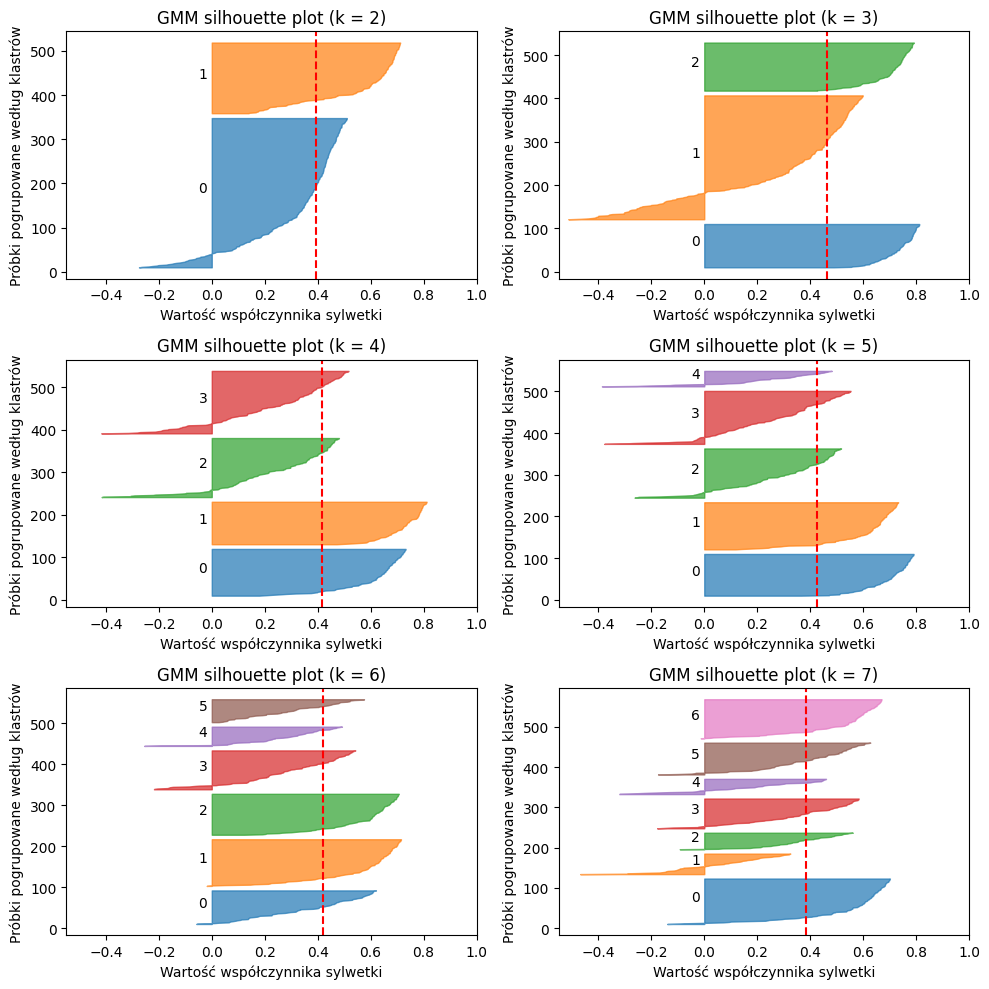

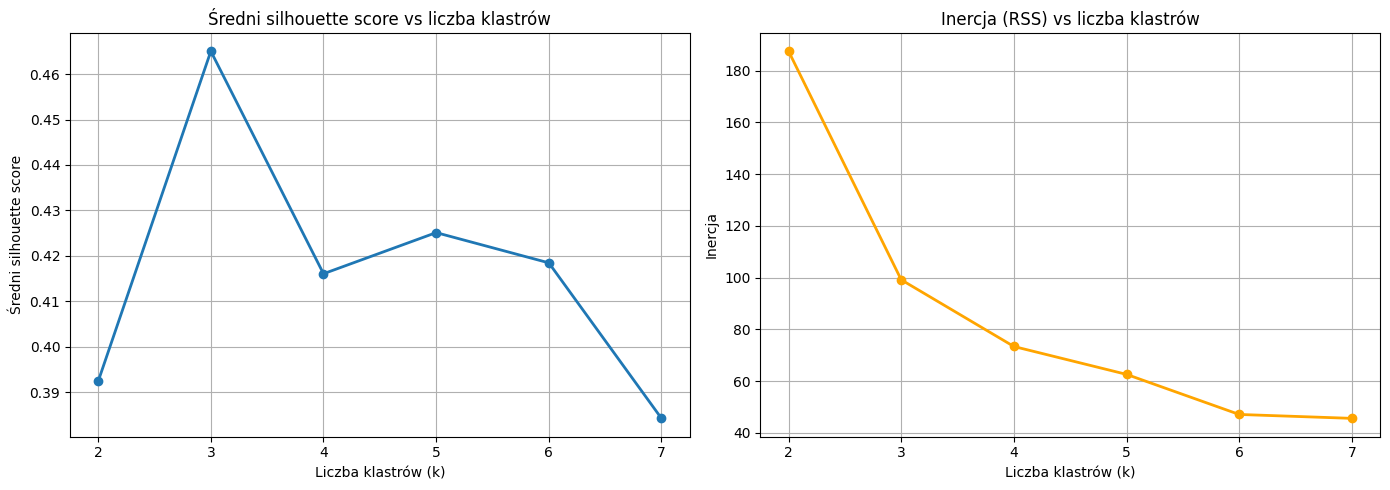

k | silhouette | RSS
2 | 0.3924 | 187.51
3 | 0.4650 | 99.16
4 | 0.4161 | 73.39
5 | 0.4251 | 62.61
6 | 0.4185 | 47.12
7 | 0.3843 | 45.60


In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score

cluster_range = [2, 3, 4, 5, 6, 7]

silhouette_scores = []
rss_values = []

# Wykresy do wizualizacji danych
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for idx, k in enumerate(cluster_range):
    ax = axes[idx]

    # Model GMM z k klastrami
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(data_X)
    labels = gmm.predict(data_X)

    # Silhouette
    silhouette_avg = silhouette_score(data_X, labels)
    sample_silhouette_values = silhouette_samples(data_X, labels)
    silhouette_scores.append(silhouette_avg)

    # RSS (inercja)
    means = gmm.means_
    rss = np.sum([np.sum((data_X[labels == i] - means[i])**2) for i in range(k)])
    rss_values.append(rss)

    # Wykres sylwetek
    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.tab10(i)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + size_cluster_i / 2, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_title(f"GMM silhouette plot (k = {k})")
    ax.set_xlabel("Wartość współczynnika sylwetki")
    ax.set_ylabel("Próbki pogrupowane według klastrów")
    ax.set_xlim([-0.55, 1])

plt.tight_layout()
plt.show()

# Wykres trendów
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette trend
ax[0].plot(cluster_range, silhouette_scores, marker='o', linewidth=2)
ax[0].set_title("Średni silhouette score vs liczba klastrów")
ax[0].set_xlabel("Liczba klastrów (k)")
ax[0].set_ylabel("Średni silhouette score")
ax[0].grid(True)

# RSS trend
ax[1].plot(cluster_range, rss_values, marker='o', color='orange', linewidth=2)
ax[1].set_title("Inercja (RSS) vs liczba klastrów")
ax[1].set_xlabel("Liczba klastrów (k)")
ax[1].set_ylabel("Inercja")
ax[1].grid(True)

plt.tight_layout()
plt.show()

#Wyniki liczbowe
print("k | silhouette | RSS")
for k, sil, rss in zip(cluster_range, silhouette_scores, rss_values):
    print(f"{k} | {sil:.4f} | {rss:.2f}")


**KOmentarz do problemu wyboru optymalnej liczby klastrów**

W ramach zadania drugiego przeprowadziłem analizę mającą na celu wybór optymalnej liczby klastrów dla zbioru danych mouse. W tym celu dopasowałem modele Gaussian Mixture Model (GMM) dla liczby klastrów od 2 do 7, a następnie oceniłem jakość uzyskanych podziałów przy użyciu dwóch niezależnych metod: współczynnika sylwetki (silhouette score) oraz inercji (Within-Cluster Sum-of-Squares), interpretowanej zgodnie z metodą łokciową. Pierwszym etapem była analiza silhouette score. Dla każdego modelu obliczyłem wartości silhouette dla poszczególnych punktów, a następnie przedstawiłem je na wykresach sylwetek, grupując próbki według przypisanych im klastrów. Dodatkowo obliczyłem średnią wartość silhouette score dla całego zbioru dla każdej liczby klastrów. Najwyższą średnią wartość uzyskałem dla modelu z trzema klastrami, co jest zgodne z rzeczywistą strukturą zbioru mouse. Warto jednak zauważyć, że różnice między wartościami silhouette dla różnych liczności klastrów były stosunkowo niewielkie, rzędu kilkunastu procent. Oznacza to, że gdyby rzeczywista liczba klastrów nie była znana z góry, wybór k = 3 nie byłby całkowicie oczywisty, a analiza silhouette mogłaby prowadzić do pewnych wątpliwości.

Drugą metodą była analiza inercji, czyli sumy kwadratów odległości punktów od centrów przypisanych im klastrów. Dla każdej liczby klastrów obliczyłem wartość RSS i przedstawiłem ją na wykresie jako funkcję k. Zgodnie z teorią inercja zawsze maleje wraz ze wzrostem liczby klastrów, dlatego metoda łokciowa polega na znalezieniu punktu, w którym tempo spadku wyraźnie się zmniejsza. W przypadku zbioru mouse krzywa RSS nie wykazywała jednoznacznego, ostrego załamania. Można było zauważyć pewne spowolnienie spadku w okolicach k = 3 lub k = 4, jednak nie było to wystarczająco wyraźne, aby jednoznacznie wskazać optymalną liczbę klastrów. Podobnie jak w przypadku silhouette score, liczba trzy wydaje się jednym z najbardziej uzasadnionych wyborów, ale metoda łokciowa sama w sobie nie pozwala na wybór tej wartości z pełnym przekonaniem. Podsumowując, obie zastosowane metody sugerują, że liczba klastrów równa trzy jest rozsądnym i dobrze uzasadnionym wyborem dla zbioru mouse, co jest zgodne z rzeczywistą strukturą danych. Jednocześnie żadna z metod nie daje w tym przypadku w pełni jednoznacznej odpowiedzi, gdy nie znamy prawdziwej liczby klastrów. Różnice między modelami są stosunkowo subtelne, a krzywa inercji nie wykazuje wyraźnego punktu łokciowego. W praktyce oznacza to, że wybór optymalnej liczby klastrów w tym zbiorze nie jest trywialny i wymagałby dodatkowych kryteriów